**1. Install neccesary library**





In [30]:
!pip install pyspellchecker==0.5.6
!pip install autocorrect
!pip install neattext
!pip install nltk
!pip install symspellpy
!pip install contractions
import nltk
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('averaged_perceptron_tagger')

  Using cached pyspellchecker-0.5.6-py2.py3-none-any.whl.metadata (8.1 kB)
Using cached pyspellchecker-0.5.6-py2.py3-none-any.whl (2.5 MB)
     ---------------------------------------- 0.0/622.8 kB ? eta -:--:--
      --------------------------------------- 10.2/622.8 kB ? eta -:--:--
     - ----------------------------------- 20.5/622.8 kB 165.2 kB/s eta 0:00:04
     - ----------------------------------- 30.7/622.8 kB 187.9 kB/s eta 0:00:04
     --- --------------------------------- 51.2/622.8 kB 238.1 kB/s eta 0:00:03
     ----- ------------------------------- 92.2/622.8 kB 403.5 kB/s eta 0:00:02
     ------------- ---------------------- 225.3/622.8 kB 811.5 kB/s eta 0:00:01
     -------------------- ----------------- 337.9/622.8 kB 1.1 MB/s eta 0:00:01
     ------------------------------- ------ 522.2/622.8 kB 1.5 MB/s eta 0:00:01
     -------------------------------------- 622.8/622.8 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): 

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger.zip.


True

**2. Load data**

In [50]:
import pandas as pd
df = pd.read_csv("../code/resources/text.csv")

In [51]:
df

,text,Label
0,i just feel really helpless and heavy hearted,fear
1,ive enjoyed being able to slouch about relax and unwind and frankly needed it after those last few weeks around the end of uni and the expo i have lately started to find myself feeling a bit listless which is never really a good thing,sadness
2,i gave up my internship with the dmrg and am feeling distraught,fear
3,i dont know i feel so lost,sadness
4,i am a kindergarten teacher and i am thoroughly weary of my job after having taken the university entrance exam i suffered from anxiety for weeks as i did not want to carry on with my work studies were the only alternative,fear
...,...,...
416804,i feel like telling these horny devils to find a site more suited to that sort of interest the playboy if there is one forum perhaps,love
416805,i began to realize that when i was feeling agitated or restless that i would have a thought to go do the dishes,anger
416806,i feel very curious be why previous early dawn in the time here don t you seek his trouble,surprise
416807,i feel that becuase of the tyranical nature of the government in el salvador and the savage social conditions of the general people that the set of thought to run the shoe shop in miguel marmols testimoney was able to work,anger


**3. Understanding data**

In [32]:
# EDA
import pandas as pd
import numpy as np

# Load Data Viz Pkgs
import seaborn as sns

# Load Text Cleaning Pkgs
import neattext.functions as nfx

# Load ML Pkgs
# Estimators
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

# Transformers
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [36]:
df['Label'].value_counts()

Label
joy         141067
sadness     121187
anger        57317
fear         47712
love         34554
surprise     14972
Name: count, dtype: int64

<Axes: xlabel='label', ylabel='count'>

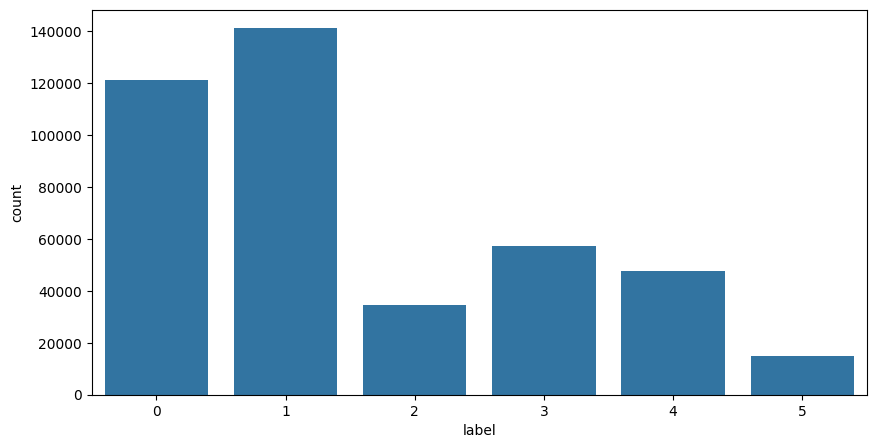

In [ ]:
sns.countplot(x='label',data=df)

**4. Preprocess data (cleaning, tokenize,...)**

In [ ]:
# Data Cleaning
dir(nfx)

['BTC_ADDRESS_REGEX',
 'CURRENCY_REGEX',
 'CURRENCY_SYMB_REGEX',
 'Counter',
 'DATE_REGEX',
 'EMAIL_REGEX',
 'EMOJI_REGEX',
 'HASTAG_REGEX',
 'MASTERCard_REGEX',
 'MD5_SHA_REGEX',
 'MOST_COMMON_PUNCT_REGEX',
 'NUMBERS_REGEX',
 'PHONE_REGEX',
 'PoBOX_REGEX',
 'SPECIAL_CHARACTERS_REGEX',
 'STOPWORDS',
 'STOPWORDS_de',
 'STOPWORDS_en',
 'STOPWORDS_es',
 'STOPWORDS_fr',
 'STOPWORDS_ru',
 'STOPWORDS_yo',
 'STREET_ADDRESS_REGEX',
 'TextFrame',
 'URL_PATTERN',
 'USER_HANDLES_REGEX',
 'VISACard_REGEX',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__generate_text',
 '__loader__',
 '__name__',
 '__numbers_dict',
 '__package__',
 '__spec__',
 '_lex_richness_herdan',
 '_lex_richness_maas_ttr',
 'clean_text',
 'defaultdict',
 'digit2words',
 'extract_btc_address',
 'extract_currencies',
 'extract_currency_symbols',
 'extract_dates',
 'extract_emails',
 'extract_emojis',
 'extract_hashtags',
 'extract_html_tags',
 'extract_mastercard_addr',
 'extract_md5sha',
 'extract_numbers',
 'extr

In [ ]:
#Remove multiple space
import re
def remove_multiple_spaces(text):
    return re.sub(r'\s+', ' ', text).strip()
df['Clean_Text'] = df['text'].apply(remove_multiple_spaces)

In [ ]:
#Expand contractions
import contractions
df['Clean_Text'] = df['text'].apply(lambda x: contractions.fix(x))
df['Clean_Text'] = df['Clean_Text'].apply(lambda x: x.replace(' ill ', ' I will '))

In [ ]:
# Remove user handles
df['Clean_Text'] = df['Clean_Text'].apply(nfx.remove_userhandles)

In [ ]:
# Remove stopwords
df['Clean_Text'] = df['Clean_Text'].apply(nfx.remove_stopwords)

In [ ]:
#Lemmatize data
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

lemmatizer = WordNetLemmatizer()
from nltk.corpus import wordnet
def get_wordnet_pos(word):
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ,
                "N": wordnet.NOUN,
                "V": wordnet.VERB,
                "R": wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN)
def lemmatize_text(text):
    words = nltk.word_tokenize(text)
    lemmatized_words = [lemmatizer.lemmatize(word, get_wordnet_pos(word)) for word in words]
    return ' '.join(lemmatized_words)

df['Clean_Text'] = df['Clean_Text'].apply(lemmatize_text)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [ ]:
#Remove miss spelled word
import re
import pandas as pd
from spellchecker import SpellChecker

spell = SpellChecker()
def reduce_elongation(word):
    return re.sub(r'(.)\1{2,}', r'\1', word)
def clean_word(word):
    word = reduce_elongation(word.lower())
    if word in spell:
        return word
    correction = spell.correction(word)
    if not correction or correction not in spell:
        return ''

    return correction
def clean_text(text):
    words = text.split()
    cleaned_words = [clean_word(w) for w in words]
    return ' '.join(filter(None, cleaned_words))


df['Final_Text'] = df['Clean_Text'].apply(clean_text)

In [ ]:
#Drop missing rows
df = df.dropna(subset=['Final_Text'])

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),    
    sublinear_tf=True,     
    max_df=0.9,             
    min_df=5,               
    max_features=50000,    
)
Xfeatures = df['Final_Text']
ylabels = df['label']
X_tfidf = vectorizer.fit_transform(Xfeatures)

**5. Analyze data**

In [57]:
import pandas as pd
df = pd.read_csv("../code/resources/newPreprocess.csv")
df = df.dropna(subset=['Final_Text'])
df_sadness = df[df['label']==0]
df_joy = df[df['label']==1]
df_love = df[df['label']==2]
df_anger = df[df['label']==3]
df_fear = df[df['label']==4]
df_surprise = df[df['label']==5]
combined_all_text = ' '.join(df['Final_Text'])
combined_sadness_text = ' '.join(df_sadness['Final_Text'])
combined_joy_text = ' '.join(df_joy['Final_Text'])
combined_love_text = ' '.join(df_love['Final_Text'])
combined_anger_text = ' '.join(df_anger['Final_Text'])
combined_fear_text = ' '.join(df_fear['Final_Text'])
combined_surprise_text = ' '.join(df_surprise['Final_Text'])
from collections import Counter
from IPython.display import display

# Set option to display all text in each cell
pd.set_option('display.max_colwidth', None)

# First, create a dictionary of top 100 words for each category (ignoring counts)
texts = {
    "All": combined_all_text,
    "Sadness": combined_sadness_text,
    "Joy": combined_joy_text,
    "Love": combined_love_text,
    "Anger": combined_anger_text,
    "Fear": combined_fear_text,
    "Surprise": combined_surprise_text
}

top_words_dict = {}
for category, text in texts.items():
    tokens = text.split()  # simple tokenization; adjust if necessary
    counter = Counter(tokens)
    top_words = [word for word, count in counter.most_common(100)]
    top_words_dict[category] = top_words

# Build a table showing the difference between the top 50 in "All" and in each other category.
data = []
all_set = set(top_words_dict["All"])
for category, words in top_words_dict.items():
    if category == "All":
        continue
    cat_set = set(words)
    # Calculate the words unique in the category (that do not appear in "All")
    unique_in_cat = sorted(cat_set - all_set)
    data.append({
        "Category": category,
        "Unique in Category (not in All)": ", ".join(unique_in_cat)
         })

df_diff = pd.DataFrame(data)

# Display the resulting table with full cell content
display(df_diff)

,Category,Unique in Category (not in All)
0,Sadness,"abuse, ache, awful, awkward, boring, burden, completely, defeat, depressed, disappointed, discourage, drain, dull, embarrass, emotional, exhaust, guilty, hat, helpless, homesick, hopeless, horrible, ignore, isolated, lethargic, lonely, low, miserable, numb, reject, shitty, sorry, stupid, suffer, terrible, unhappy, useless, worthless"
1,Joy,"accepted, bless, calm, comfortable, confident, content, cool, creative, cute, enjoy, excite, free, glad, important, inspire, lucky, ok, perfect, positive, productive, proud, relaxed, respect, safe, satisfied, special, strong, successful, super, thankful, trust, value, wonderful"
2,Love,"accepted, affectionate, beloved, bless, compassionate, delicate, devote, face, faithful, fond, generous, gentle, hand, horny, hot, longing, lovely, loyal, naughty, nostalgic, old, passionate, romantic, slutty, supportive, sympathetic, tender, touch, understand, woman"
3,Anger,"agitate, annoyed, bitchy, bitter, bother, cold, cranky, dangerous, disgust, dissatisfied, distract, envious, frustrate, fuck, greedy, grouchy, grumpy, hat, heartless, hostile, impatient, insult, irritable, irritated, jealous, mad, offend, petty, piss, reason, rebellious, resentful, rude, rush, selfish, stubborn, torture, violent, wrong"
4,Fear,"afraid, agitate, anxious, apprehensive, confuse, distraught, distressed, doubtful, fear, fearful, frantic, frighten, helpless, hesitant, insecure, intimidate, nervous, overwhelmed, paranoid, pressure, reluctant, restless, scar, shaken, shaky, shy, skeptical, strange, suspicious, terrify, threaten, torture, uncertain, uncomfortable, unsure, uptight, vulnerable, weird"
5,Surprise,"body, completely, confuse, curious, daze, enthral, face, funny, head, impressed, learn, month, overwhelmed, see, sense, shock, sit, slightly, sort, story, strange, stun, surprised, weird"


In [58]:
pip install wordcloud

   ---------------------------------------- 0.0/299.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/299.9 kB ? eta -:--:--
   --- ----------------------------------- 30.7/299.9 kB 325.1 kB/s eta 0:00:01
   ----------- --------------------------- 92.2/299.9 kB 655.4 kB/s eta 0:00:01
   ------------------ ------------------- 143.4/299.9 kB 847.9 kB/s eta 0:00:01
   ---------------------------------- ----- 256.0/299.9 kB 1.2 MB/s eta 0:00:01
   ---------------------------------------- 299.9/299.9 kB 1.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


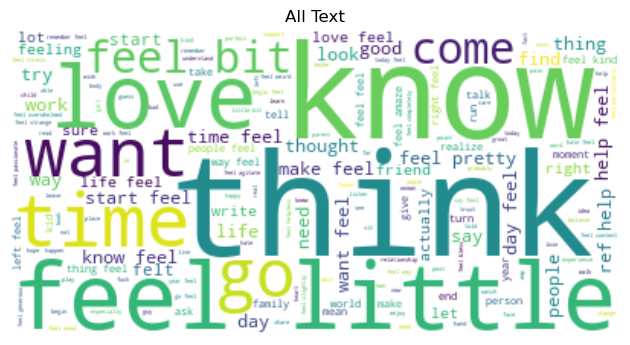

In [59]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
all_wordcloud = WordCloud(background_color='white').generate(combined_all_text)
sadness_wordcloud = WordCloud(width=1200, height=600, background_color='white').generate(combined_sadness_text)
joy_wordcloud = WordCloud(width=1200, height=600, background_color='white').generate(combined_joy_text)
love_wordcloud = WordCloud(width=1200, height=600, background_color='white').generate(combined_love_text)
anger_wordcloud = WordCloud(width=1200, height=600, background_color='white').generate(combined_anger_text)
fear_wordcloud = WordCloud(width=1200, height=600, background_color='white').generate(combined_fear_text)
surprise_wordcloud = WordCloud(width=1200, height=600, background_color='white').generate(combined_surprise_text)
plt.imshow(all_wordcloud, interpolation='bilinear')
plt.title('All Text')
plt.axis('off')

plt.tight_layout()
# plt.savefig("alltext.jpg", dpi=300)
plt.show()

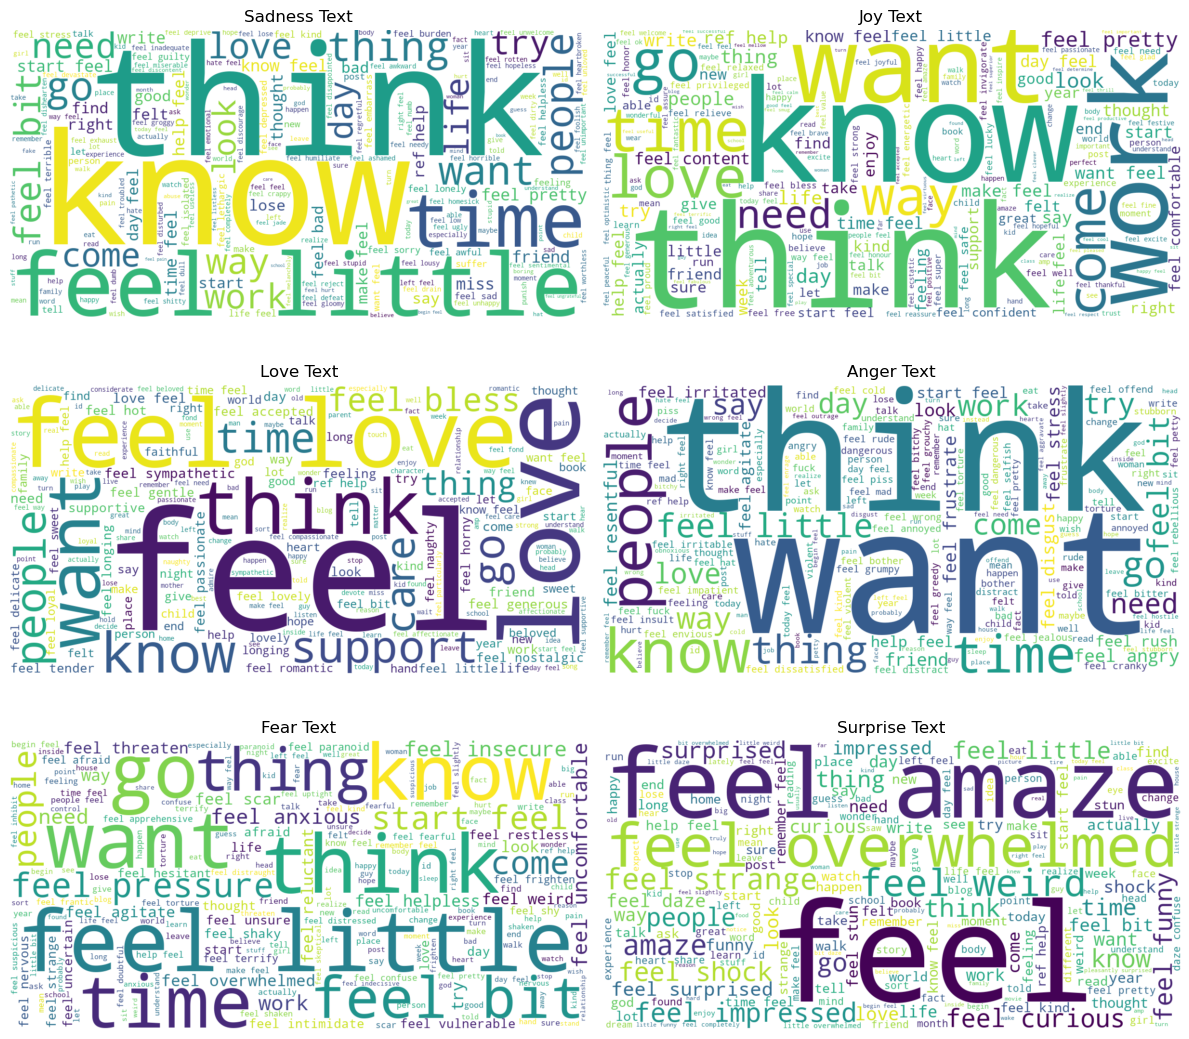

In [60]:
plt.figure(figsize=(12, 11))  # Adjust the figure size as needed

plt.subplot(3, 2, 1)
plt.imshow(sadness_wordcloud, interpolation='bilinear')
plt.title('Sadness Text')
plt.axis('off')

plt.subplot(3, 2, 2)
plt.imshow(joy_wordcloud, interpolation='bilinear')
plt.title('Joy Text')
plt.axis('off')

plt.subplot(3, 2, 3)
plt.imshow(love_wordcloud, interpolation='bilinear')
plt.title('Love Text')
plt.axis('off')

plt.subplot(3, 2, 4)
plt.imshow(anger_wordcloud, interpolation='bilinear')
plt.title('Anger Text')
plt.axis('off')

plt.subplot(3, 2, 5)
plt.imshow(fear_wordcloud, interpolation='bilinear')
plt.title('Fear Text')
plt.axis('off')

plt.subplot(3, 2, 6)
plt.imshow(surprise_wordcloud, interpolation='bilinear')
plt.title('Surprise Text')
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
token_lengths = df['Final_Text'].apply(lambda x: len(x.split()))
length_series = pd.Series(token_lengths)
mean_length = length_series.mean()
median_length = length_series.median()
mode_length = length_series.mode().iloc[0]
std_dev = length_series.std()
min_length = length_series.min()
max_length = length_series.max()
print(f"Mean Length: {mean_length:.2f}")
print(f"Median Length: {median_length}")
print(f"Mode Length: {mode_length}")
print(f"Standard Deviation: {std_dev:.2f}")
print(f"Min Length: {min_length}")
print(f"Max Length: {max_length}")

Mean Length: 7.79
Median Length: 7.0
Mode Length: 4
Standard Deviation: 4.37
Min Length: 1
Max Length: 65


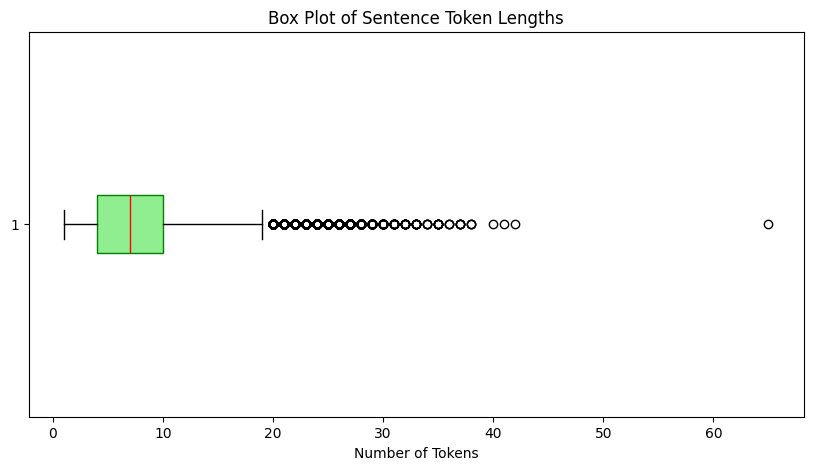

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.boxplot(token_lengths, vert=False, patch_artist=True,
            boxprops=dict(facecolor="lightgreen", color="green"),
            medianprops=dict(color="red"))
plt.xlabel('Number of Tokens')
plt.title('Box Plot of Sentence Token Lengths')
plt.show()


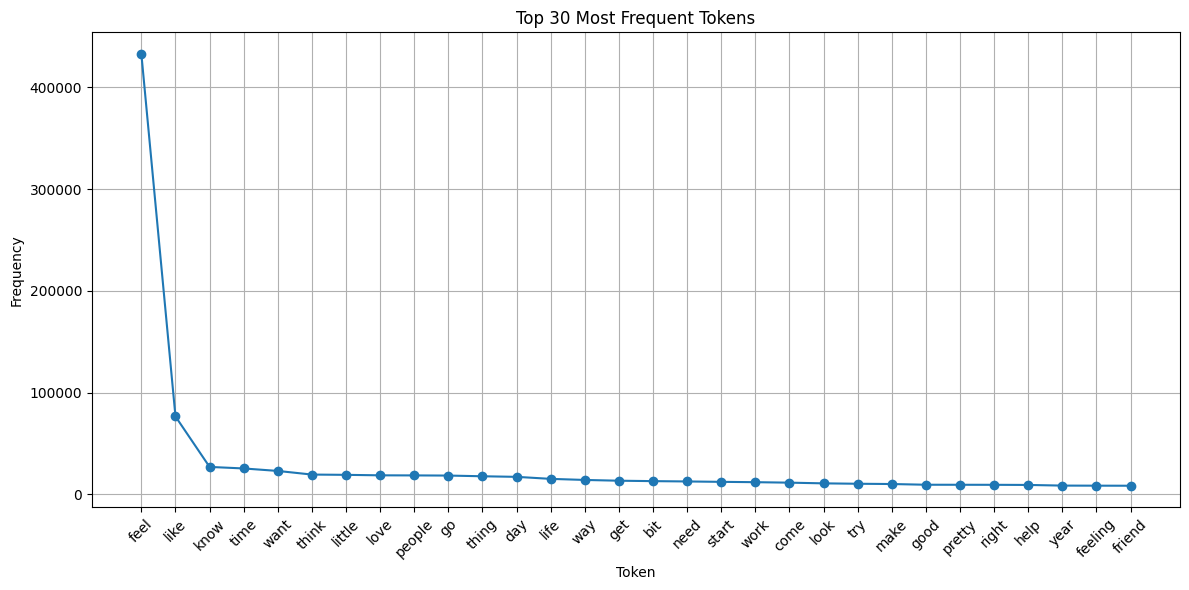

In [ ]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
all_tokens = ' '.join(df['Final_Text']).split()
token_counts = Counter(all_tokens)
freq_df = pd.DataFrame(token_counts.items(), columns=['Token', 'Frequency'])
freq_df = freq_df.sort_values(by='Frequency', ascending=False).reset_index(drop=True)
top_n = 30
top_freq_df = freq_df.head(top_n)
plt.figure(figsize=(12, 6))
plt.plot(top_freq_df['Token'], top_freq_df['Frequency'], marker='o')
plt.xticks(rotation=45)
plt.title(f'Top {top_n} Most Frequent Tokens')
plt.xlabel('Token')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()



**Logistic regression**


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.92      0.94    121182
           1       0.95      0.89      0.92    141061
           2       0.73      0.92      0.82     34554
           3       0.91      0.92      0.91     57306
           4       0.88      0.86      0.87     47706
           5       0.68      0.98      0.80     14972

    accuracy                           0.91    416781
   macro avg       0.86      0.92      0.88    416781
weighted avg       0.92      0.91      0.91    416781

Accuracy:  0.9070
Precision: 0.9160
Recall:    0.9070
F1 Score:  0.9091


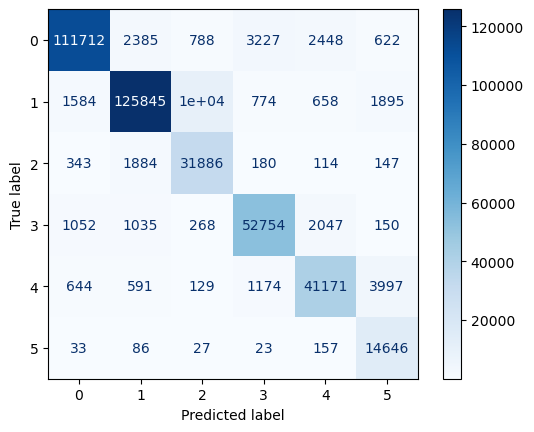

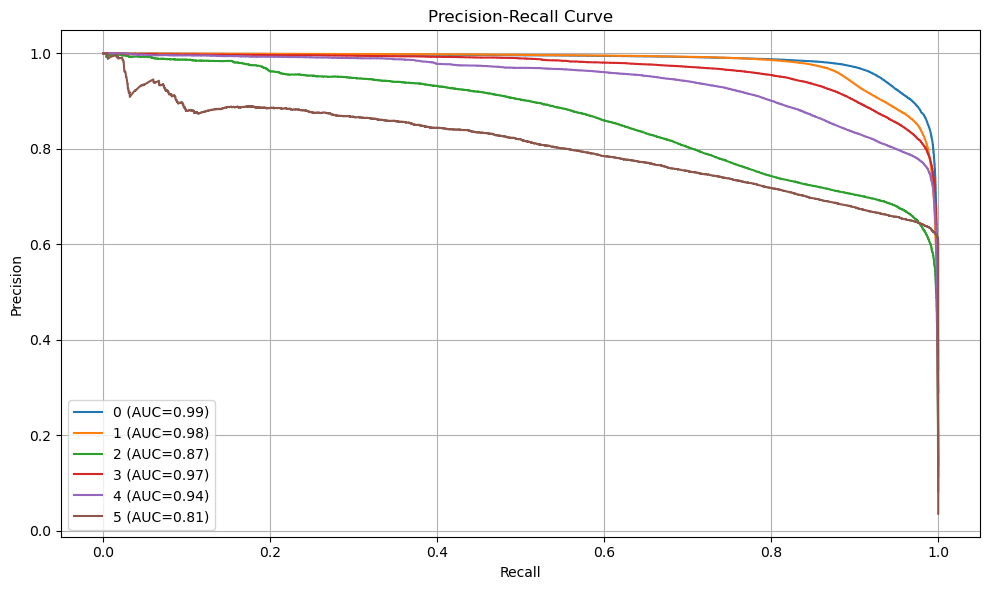

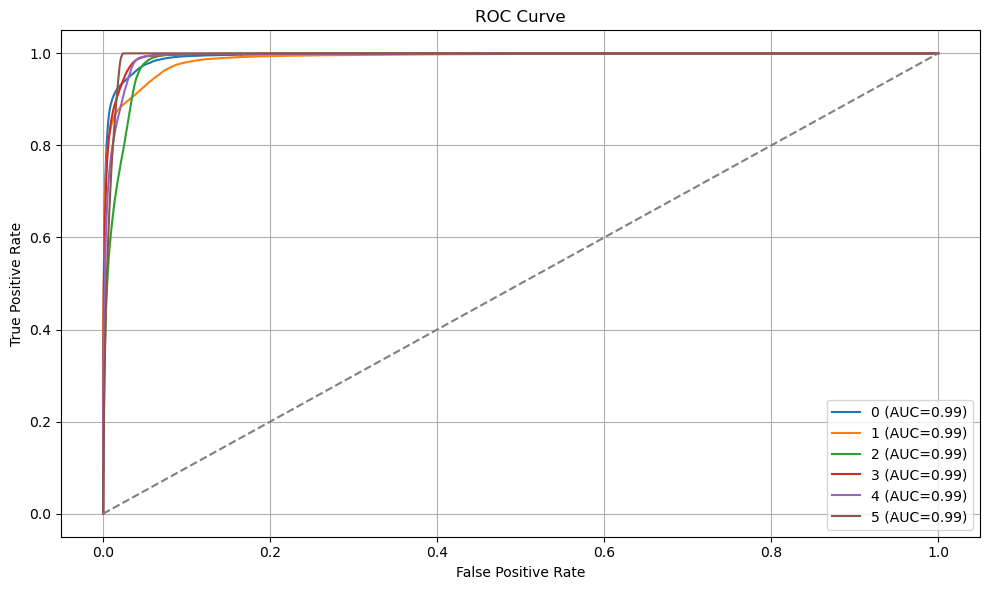

In [ ]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score,
    f1_score, classification_report, accuracy_score,
    roc_curve, auc, precision_recall_curve, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.preprocessing import label_binarize
import joblib

df = pd.read_csv("../code/resources/newPreprocess.csv")
df = df.dropna(subset=['Final_Text'])

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    sublinear_tf=True,
    max_df=0.85,
    min_df=5,
    max_features=50000,
    stop_words='english',
)
Xfeatures = df['Final_Text']
ylabels = df['label']
X_tfidf = vectorizer.fit_transform(Xfeatures)
sgd_classifier = SGDClassifier(
    loss='modified_huber',
    penalty='l2',
    class_weight='balanced',
    alpha=0.0001,
    max_iter=1000,
    tol=1e-3
)

# Cross-validated predictions (labels and scores)
y_pred = cross_val_predict(sgd_classifier, X_tfidf, ylabels, cv=10)
y_scores = cross_val_predict(sgd_classifier, X_tfidf, ylabels, cv=10, method='decision_function')

# Confusion matrix
cm = confusion_matrix(ylabels, y_pred, labels=np.unique(ylabels))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(ylabels))
disp.plot(cmap='Blues')

# Classification report and metrics
print("\nClassification Report:")
print(classification_report(ylabels, y_pred))
print(f"Accuracy:  {accuracy_score(ylabels, y_pred):.4f}")
print(f"Precision: {precision_score(ylabels, y_pred, average='weighted'):.4f}")
print(f"Recall:    {recall_score(ylabels, y_pred, average='weighted'):.4f}")
print(f"F1 Score:  {f1_score(ylabels, y_pred, average='weighted'):.4f}")

# Binarize labels for PR/ROC curve
classes = np.unique(ylabels)
y_bin = label_binarize(ylabels, classes=classes)
if y_bin.shape[1] == 1:
    y_bin = np.hstack((1 - y_bin, y_bin))  # for binary case
    classes = [f'not-{classes[0]}', classes[0]]

# Ensure y_scores shape matches
if y_scores.ndim == 1 or y_scores.shape[1] != y_bin.shape[1]:
    # Fit manually to get decision_function outputs with shape [n_samples, n_classes]
    sgd_classifier.fit(X_tfidf, ylabels)
    y_scores = sgd_classifier.decision_function(X_tfidf)
    if y_scores.ndim == 1:
        y_scores = np.vstack([-y_scores, y_scores]).T  # binary case

# Plot Precision-Recall curves
plt.figure(figsize=(10, 6))
for i, class_name in enumerate(classes):
    precision, recall, _ = precision_recall_curve(y_bin[:, i], y_scores[:, i])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'{class_name} (AUC={pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot ROC curves
plt.figure(figsize=(10, 6))
for i, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_scores[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_name} (AUC={roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.92      0.95    121182
           1       0.96      0.90      0.93    141061
           2       0.74      0.92      0.82     34554
           3       0.91      0.92      0.91     57306
           4       0.88      0.86      0.87     47706
           5       0.68      0.98      0.80     14972

    accuracy                           0.91    416781
   macro avg       0.86      0.92      0.88    416781
weighted avg       0.92      0.91      0.91    416781

Accuracy:  0.9085
Precision: 0.9174
Recall:    0.9085
F1 Score:  0.9106


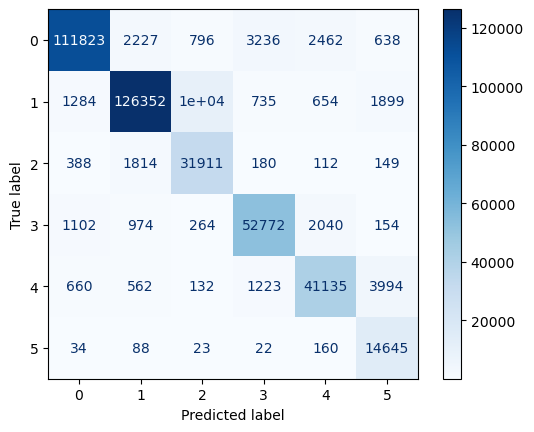

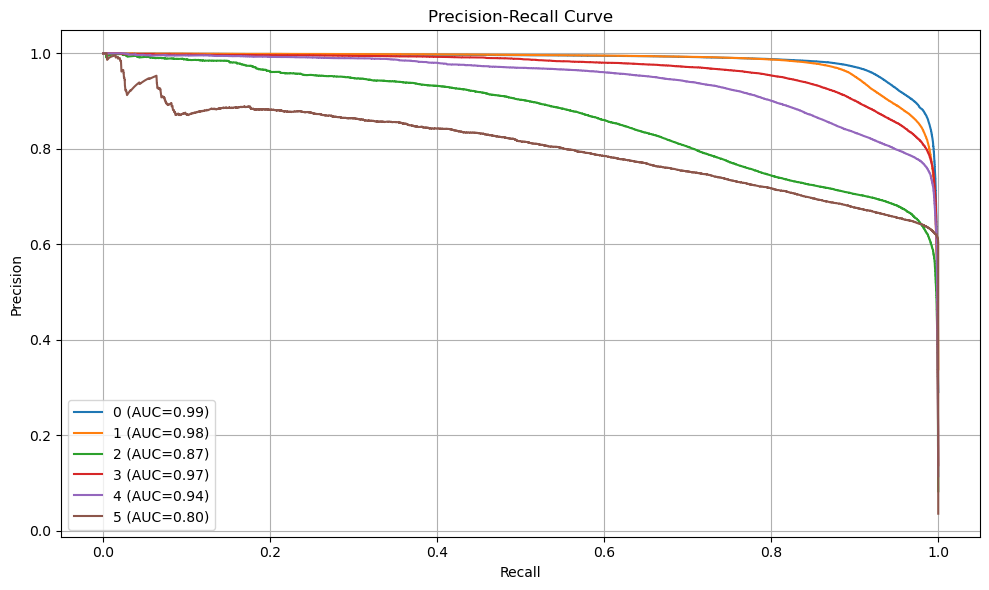

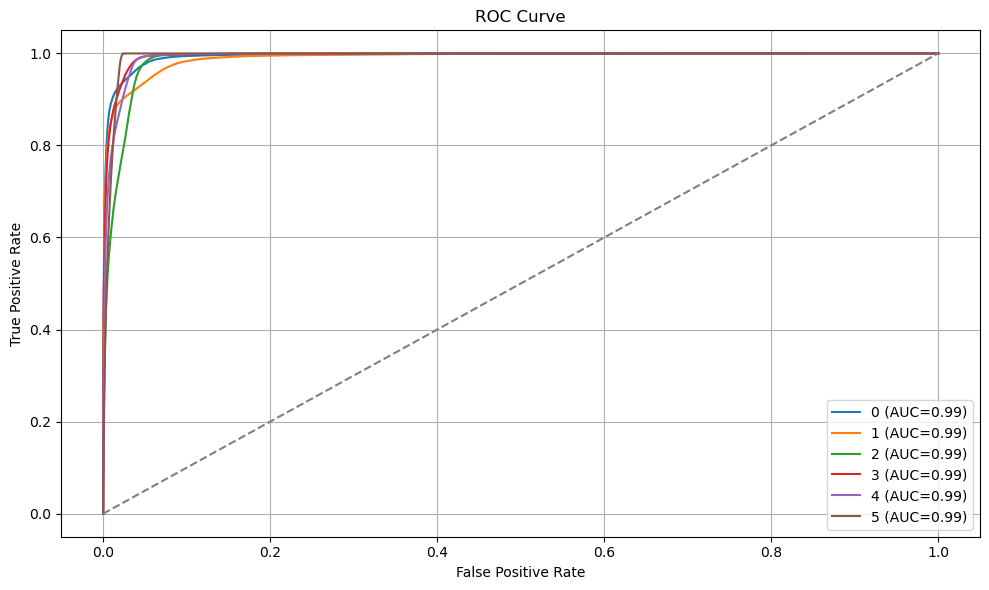

In [ ]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score,
    f1_score, classification_report, accuracy_score,
    roc_curve, auc, precision_recall_curve, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.preprocessing import label_binarize
import joblib

df = pd.read_csv("../code/resources/newPreprocess.csv")
df = df.dropna(subset=['Final_Text'])

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    sublinear_tf=True,
    max_df=0.9,
    min_df=5,
    max_features=50000,
)
Xfeatures = df['Final_Text']
ylabels = df['label']
X_tfidf = vectorizer.fit_transform(Xfeatures)
sgd_classifier = SGDClassifier(
    loss='modified_huber',
    penalty='l2',
    class_weight='balanced',
    alpha=0.0001,
    max_iter=1000,
    tol=1e-3
)
y_pred = cross_val_predict(sgd_classifier, X_tfidf, ylabels, cv=10)
y_scores = cross_val_predict(sgd_classifier, X_tfidf, ylabels, cv=10, method='decision_function')
cm = confusion_matrix(ylabels, y_pred, labels=np.unique(ylabels))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(ylabels))
disp.plot(cmap='Blues')
print("\nClassification Report:")
print(classification_report(ylabels, y_pred))
print(f"Accuracy:  {accuracy_score(ylabels, y_pred):.4f}")
print(f"Precision: {precision_score(ylabels, y_pred, average='weighted'):.4f}")
print(f"Recall:    {recall_score(ylabels, y_pred, average='weighted'):.4f}")
print(f"F1 Score:  {f1_score(ylabels, y_pred, average='weighted'):.4f}")

# Binarize labels for PR/ROC curve
classes = np.unique(ylabels)
y_bin = label_binarize(ylabels, classes=classes)
if y_bin.shape[1] == 1:
    y_bin = np.hstack((1 - y_bin, y_bin))  # for binary case
    classes = [f'not-{classes[0]}', classes[0]]

# Ensure y_scores shape matches
if y_scores.ndim == 1 or y_scores.shape[1] != y_bin.shape[1]:
    # Fit manually to get decision_function outputs with shape [n_samples, n_classes]
    sgd_classifier.fit(X_tfidf, ylabels)
    y_scores = sgd_classifier.decision_function(X_tfidf)
    if y_scores.ndim == 1:
        y_scores = np.vstack([-y_scores, y_scores]).T  # binary case

# Plot Precision-Recall curves
plt.figure(figsize=(10, 6))
for i, class_name in enumerate(classes):
    precision, recall, _ = precision_recall_curve(y_bin[:, i], y_scores[:, i])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'{class_name} (AUC={pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot ROC curves
plt.figure(figsize=(10, 6))
for i, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_scores[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_name} (AUC={roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import os
df = pd.read_csv("../code/resources/newPreprocess.csv")
df = df.dropna(subset=['Final_Text'])

X = df['Final_Text']
y = df['label']
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2), 
        sublinear_tf=True,
        max_df=0.9,
        min_df=5,
        max_features=50000
    )),
    ('clf', SGDClassifier())
])
param_grid = {
    'clf__alpha': [1e-4, 1e-3, 1e-2],
    'clf__penalty': ['l2', 'l1', 'elasticnet'],
    'clf__loss': ['hinge', 'log_loss', 'modified_huber']
}
grid_search = GridSearchCV(pipeline, param_grid, cv=5, n_jobs=-1, scoring='accuracy', verbose=2)
grid_search.fit(X, y)
print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)


Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best Parameters: {'clf__alpha': 0.0001, 'clf__loss': 'modified_huber', 'clf__penalty': 'elasticnet'}
Best Accuracy: 0.9061545512292897



Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.93      0.92    121182
           1       0.86      0.95      0.90    141061
           2       0.91      0.58      0.71     34554
           3       0.90      0.87      0.89     57306
           4       0.86      0.84      0.85     47706
           5       0.82      0.67      0.74     14972

    accuracy                           0.88    416781
   macro avg       0.88      0.81      0.83    416781
weighted avg       0.88      0.88      0.88    416781

Accuracy:  0.8817
Precision: 0.8830
Recall:    0.8817
F1 Score:  0.8780


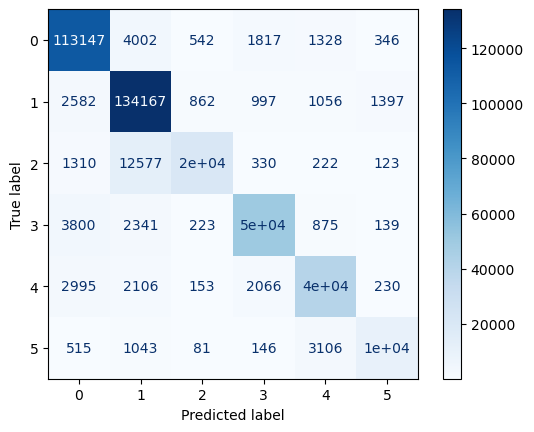

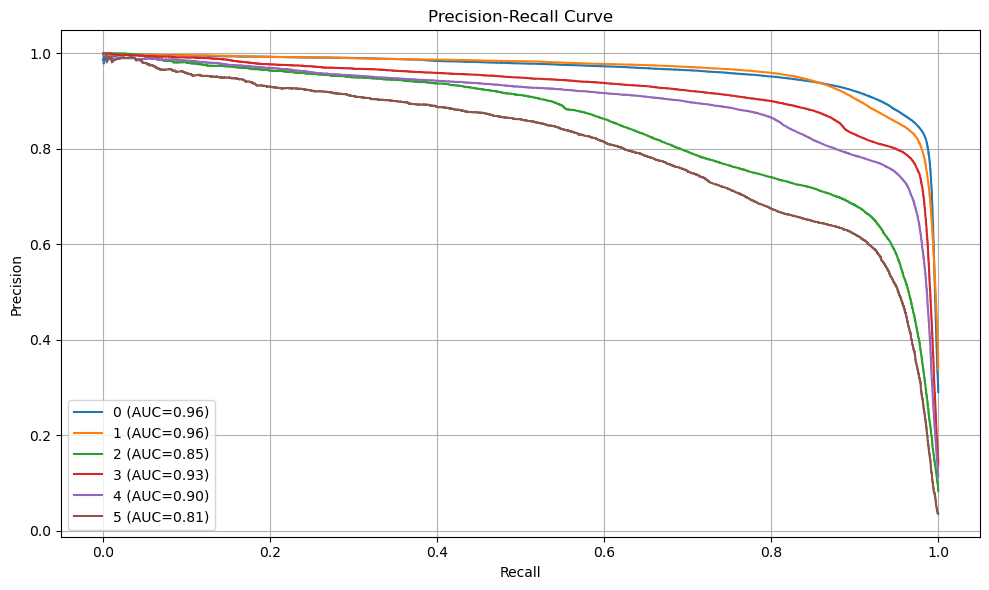

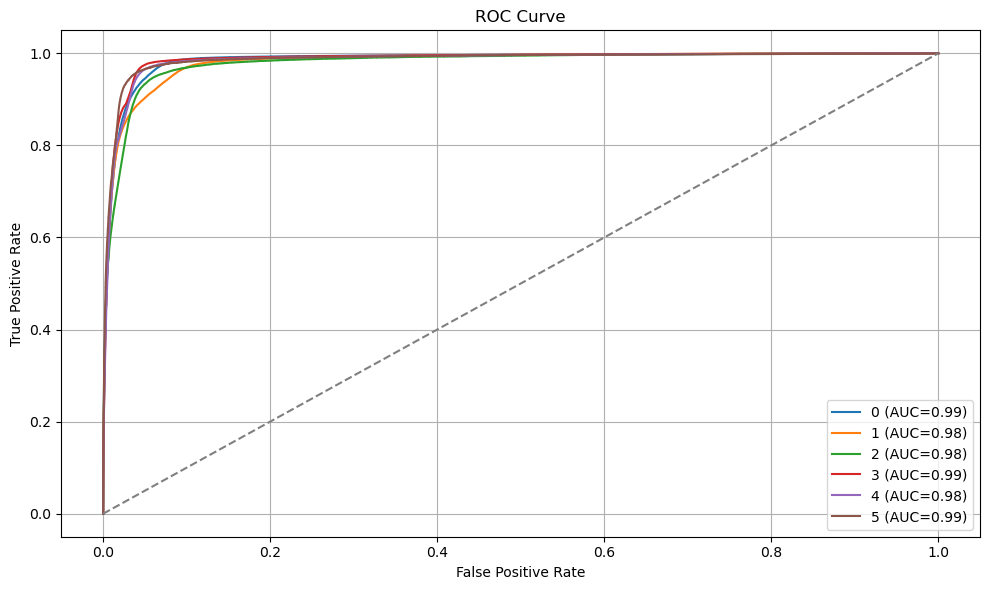

In [29]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score,
    f1_score, classification_report, accuracy_score,
    roc_curve, auc, precision_recall_curve
)
from sklearn.preprocessing import label_binarize
import joblib

df = pd.read_csv("../code/resources/newPreprocess.csv")
df = df.dropna(subset=['Final_Text'])
vectorizer = TfidfVectorizer(
)
Xfeatures = df['Final_Text']
ylabels = df['label']
X_tfidf = vectorizer.fit_transform(Xfeatures)
sgd_classifier = SGDClassifier()
y_pred = cross_val_predict(sgd_classifier, X_tfidf, ylabels, cv=10)
y_scores = cross_val_predict(sgd_classifier, X_tfidf, ylabels, cv=10, 
                             method='decision_function')
cm = confusion_matrix(ylabels, y_pred, labels=np.unique(ylabels))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels=np.unique(ylabels))
disp.plot(cmap='Blues')
print("\nClassification Report:")
print(classification_report(ylabels, y_pred))
print(f"Accuracy:  {accuracy_score(ylabels, y_pred):.4f}")
print(f"Precision: {precision_score(ylabels, y_pred, average='weighted'):.4f}")
print(f"Recall:    {recall_score(ylabels, y_pred,average='weighted'):.4f}")
print(f"F1 Score:  {f1_score(ylabels, y_pred,average='weighted'):.4f}")
classes = np.unique(ylabels)
y_bin = label_binarize(ylabels, classes=classes)
if y_bin.shape[1] == 1:
    y_bin = np.hstack((1 - y_bin, y_bin))  
    classes = [f'not-{classes[0]}', classes[0]]
if y_scores.ndim == 1 or y_scores.shape[1] != y_bin.shape[1]:
    sgd_classifier.fit(X_tfidf, ylabels)
    y_scores = sgd_classifier.decision_function(X_tfidf)
    if y_scores.ndim == 1:
        y_scores = np.vstack([-y_scores, y_scores]).T  
plt.figure(figsize=(10, 6))
for i, class_name in enumerate(classes):
    precision, recall, _ = precision_recall_curve(y_bin[:, i], y_scores[:, i])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'{class_name} (AUC={pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot ROC curves
plt.figure(figsize=(10, 6))
for i, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_scores[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_name} (AUC={roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
